In [25]:
# Mandatory questions

In [26]:
import pandas as pd

# Load the data (files are in the same folder as the notebook)
qla = pd.read_csv('task_qla_df.csv')
tia = pd.read_feather('task_tia_df.feather')

# Confirm it's loaded
print("Assessment data shape:", qla.shape)
print("Activity data shape:", tia.shape)

# Preview the assessment data
qla.head()


Assessment data shape: (5827, 11)
Activity data shape: (459115, 14)


,student_id,assessment_id,assessment_name,n_questions_entered,n_questions_attempted,n_assessment_questions,absent,mark,available_marks,created,last_updated
0,b61c4,94245,Year 7 Term 3 Assessment,36,36,36,False,34.0,60,2024-06-27 14:18:23.948111+00:00,2024-06-27 14:22:34.230140+00:00
1,d47b3,94245,Year 7 Term 3 Assessment,36,36,36,False,37.0,60,2024-07-08 13:52:46.036772+00:00,2024-07-08 14:24:42.552651+00:00
2,01093,94245,Year 7 Term 3 Assessment,36,36,36,False,42.0,60,2024-07-03 08:08:21.592102+00:00,2024-07-03 08:22:59.515326+00:00
3,2a270,94245,Year 7 Term 3 Assessment,36,36,36,False,27.0,60,2024-07-04 07:52:38.344720+00:00,2024-07-04 08:21:34.395024+00:00
4,24de5,94245,Year 7 Term 3 Assessment,36,36,36,False,37.0,60,2024-07-13 18:57:19.360425+00:00,2024-07-13 19:30:58.809699+00:00


In [27]:
## How many distinct students do we have both assessment and activity data for?

In [7]:
# Get the unique student IDs from each dataset
students_in_qla = set(qla['student_id'].unique())
students_in_tia = set(tia['student_id'].unique())

# Find the intersection: students who are in both datasets
students_in_both = students_in_qla.intersection(students_in_tia)

# Print the result
print(f"Number of students with both assessment and activity data: {len(students_in_both)}")


Number of students with both assessment and activity data: 1394


In [28]:
## For students who completed at least two assessments, what was the mean progress they made from one test to the next?

In [29]:
import numpy as np

# Step 1: Filter valid, non-absent rows and remove divisions by zero
qla_present = qla[qla['absent'] == False].copy()
qla_present = qla_present[qla_present['available_marks'] > 0].copy()

# Step 2: Calculate percentage score
qla_present['percentage_score'] = qla_present['mark'] / qla_present['available_marks'] * 100

# Step 3: Drop rows where percentage_score is NaN
qla_present.dropna(subset=['percentage_score'], inplace=True)

# Step 4: Sort by student and time
qla_present.sort_values(by=['student_id', 'last_updated'], inplace=True)

# Step 5: Compute progress values
progress_list = []

for student_id, group in qla_present.groupby('student_id'):
    if len(group) >= 2:
        scores = group['percentage_score'].values
        deltas = (scores[1:] - scores[:-1]).tolist()
        progress_list.extend(deltas)

# Step 6: Calculate and display mean progress
if progress_list:
    mean_progress = np.mean(progress_list)
    print(f"Mean progress between tests for students with at least 2 assessments: {mean_progress:.2f}%")
else:
    print("No valid progress data found.")


Mean progress between tests for students with at least 2 assessments: -3.17%


In [30]:
## Plot/visualise this ‘progress’ distribution.

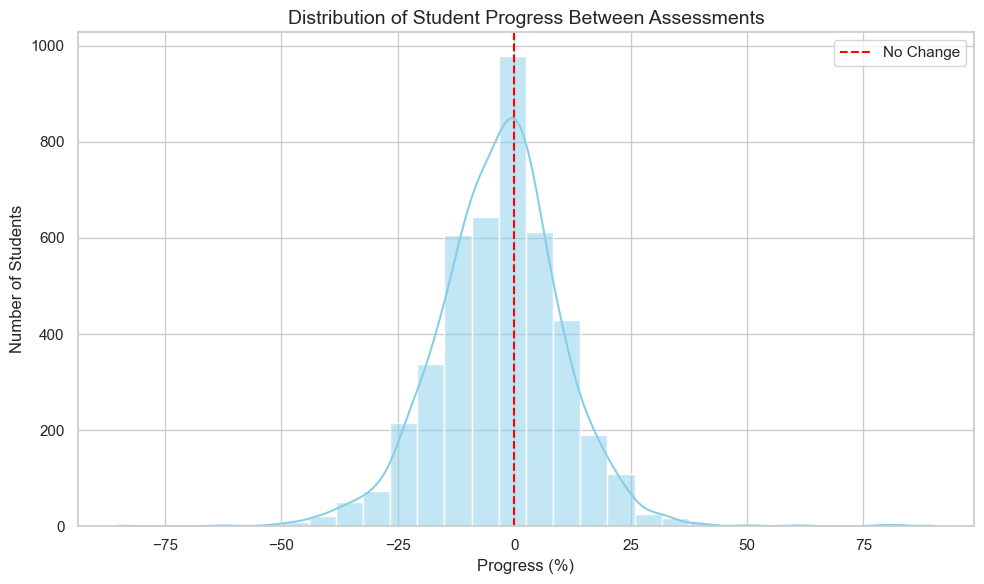

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(progress_list, kde=True, bins=30, color='skyblue')

# Labels and title
plt.title("Distribution of Student Progress Between Assessments", fontsize=14)
plt.xlabel("Progress (%)", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

# Vertical line at 0 to show improvement vs decline
plt.axvline(0, color='red', linestyle='--', label='No Change')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
On average, how did students perform in the ## second test that they sat compared to the first? Use a statistical test to explain whether or not you are confident in this result.

In [32]:
from scipy.stats import ttest_rel

# Prepare first vs second test scores
first_scores = []
second_scores = []

for student_id, group in qla_present.groupby('student_id'):
    sorted_group = group.sort_values(by='last_updated')
    scores = sorted_group['percentage_score'].values
    
    if len(scores) >= 2:
        first_scores.append(scores[0])
        second_scores.append(scores[1])

# Convert to arrays
first_scores = np.array(first_scores)
second_scores = np.array(second_scores)

# Paired t-test
t_stat, p_value = ttest_rel(second_scores, first_scores)

# Print results
mean_diff = np.mean(second_scores - first_scores)
print(f"Average change from first to second test: {mean_diff:.2f}%")
print(f"Paired t-test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("The difference is statistically significant (p < 0.05)")
else:
    print("The difference is NOT statistically significant (p ≥ 0.05)")


Average change from first to second test: -4.88%
Paired t-test p-value: 0.0000
The difference is statistically significant (p < 0.05)


In [33]:
## State one way that you might improve your confidence in your answer to question (4)

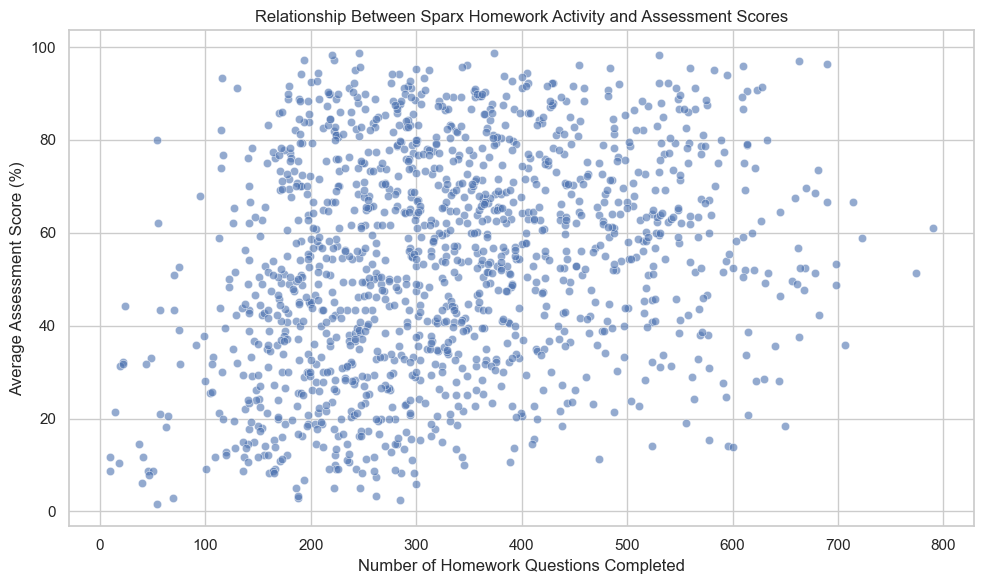

Pearson correlation: 0.26, p-value: 0.0000


In [35]:
# Step 1: Activity level per student
tia['activity_count'] = 1
activity_summary = tia.groupby('student_id')['activity_count'].count().reset_index()
activity_summary.rename(columns={'activity_count': 'num_homework_questions'}, inplace=True)

# Step 2: Average assessment score per student (non-absent and valid scores)
qla_valid = qla[(qla['absent'] == False) & (qla['available_marks'] > 0)].copy()
qla_valid['percentage_score'] = qla_valid['mark'] / qla_valid['available_marks'] * 100
assessment_summary = qla_valid.groupby('student_id')['percentage_score'].mean().reset_index()
assessment_summary.rename(columns={'percentage_score': 'avg_score'}, inplace=True)

# Step 3: Merge both summaries
merged = pd.merge(activity_summary, assessment_summary, on='student_id')

# Step 4: Plot and correlation
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='num_homework_questions', y='avg_score', alpha=0.6)
plt.title("Relationship Between Sparx Homework Activity and Assessment Scores")
plt.xlabel("Number of Homework Questions Completed")
plt.ylabel("Average Assessment Score (%)")
plt.tight_layout()
plt.show()

# Step 5: Correlation
correlation, p_val = pearsonr(merged['num_homework_questions'], merged['avg_score'])
print(f"Pearson correlation: {correlation:.2f}, p-value: {p_val:.4f}")
